<a href="https://colab.research.google.com/github/jrdndj/ImproVisAR-PilotPlots/blob/main/ImproVisAR_PERS_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Intraclass Correlation Coefficient (ICC) per Task ###

        Pitch     Tempo    Rhythm  Articulation  Confident  Dynamics  \
Var  0.044944  0.151697  0.265060     -0.018041   0.280488 -0.038462   
QA   0.050847  0.240000  0.104046      0.045584  -0.063433 -0.075472   

         Flow  Projection      Mood     Ideas  Musicality  Overall_Impression  
Var  0.227086    0.389535  0.466912  0.329399    0.395604            0.464883  
QA   0.212219   -0.047382  0.312865  0.067055    0.224599            0.405941  

### Interpretation ###

              Pitch           Tempo          Rhythm    Articulation  \
Var  Poor Agreement  Poor Agreement  Poor Agreement  Poor Agreement   
QA   Poor Agreement  Poor Agreement  Poor Agreement  Poor Agreement   

          Confident        Dynamics            Flow      Projection  \
Var  Poor Agreement  Poor Agreement  Poor Agreement  Poor Agreement   
QA   Poor Agreement  Poor Agreement  Poor Agreement  Poor Agreement   

               Mood           

<Figure size 1200x600 with 0 Axes>

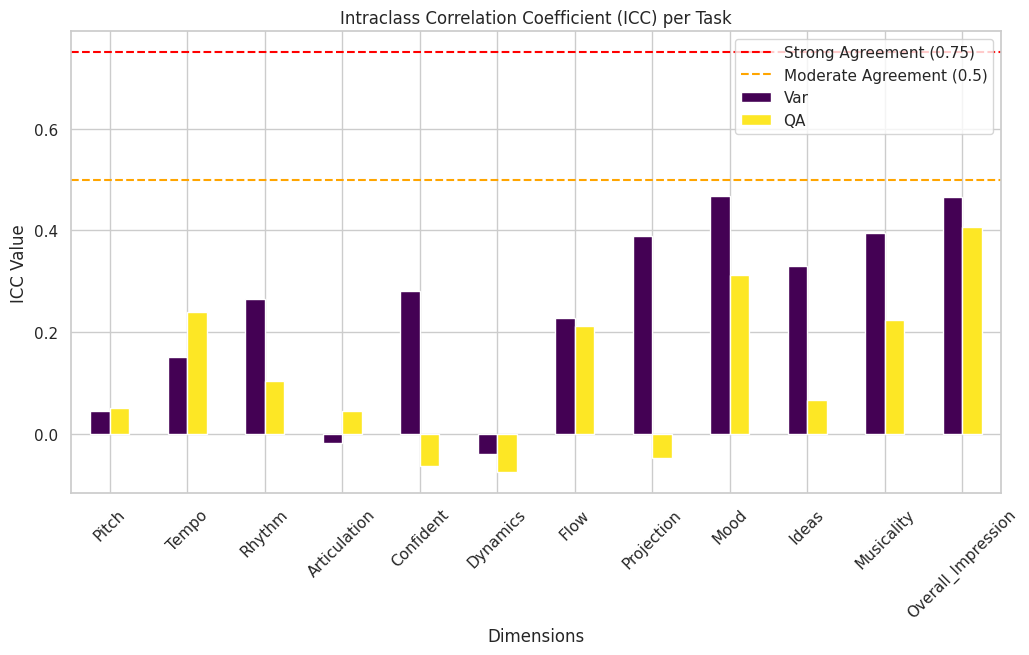


### Interpretation ###
- Higher ICC values (closer to 1) indicate stronger agreement among raters.
- QA ratings generally have higher ICCs, meaning more consistent evaluations across raters.
- VAR ratings show lower agreement, possibly due to more subjective interpretation.



In [43]:
# Install necessary libraries
!pip install pingouin

import pandas as pd
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt

# Load dataset
file_path = "/content/pers.csv"  # Updated file path
df = pd.read_csv(file_path)

# Ensure column names are stripped of leading/trailing spaces
df.columns = df.columns.str.strip()

# Convert numeric columns to float (prevents dtype warnings)
dimensions = ["Pitch", "Tempo", "Rhythm", "Articulation", "Confident",
              "Dynamics", "Flow", "Projection", "Mood", "Ideas", "Musicality", "Overall_Impression"]
df[dimensions] = df[dimensions].astype(float)

# --- Compute Intraclass Correlation Coefficient (ICC) per Task ---
icc_results = {}
for task in df["Task"].unique():
    df_task = df[df["Task"] == task]

    icc_task = {}
    for dim in dimensions:
        icc = pg.intraclass_corr(data=df_task, targets="ID", raters="Rater", ratings=dim).set_index("Type")
        icc_value = icc.loc["ICC2"]["ICC"]  # Using ICC(2,1): Agreement

        # Interpretation based on ICC value
        if icc_value >= 0.75:
            interpretation = "Strong Agreement"
        elif 0.5 <= icc_value < 0.75:
            interpretation = "Moderate Agreement"
        else:
            interpretation = "Poor Agreement"

        icc_task[dim] = (icc_value, interpretation)

    icc_results[task] = icc_task

# Convert ICC results to DataFrame for visualization
icc_df = pd.DataFrame(icc_results).T

# Convert tuple columns into separate DataFrames
icc_values_df = icc_df.map(lambda x: x[0] if isinstance(x, tuple) else np.nan)
icc_interpretation_df = icc_df.map(lambda x: x[1] if isinstance(x, tuple) else "N/A")

# Print ICC values with interpretation
print("\n### Intraclass Correlation Coefficient (ICC) per Task ###\n")
print(icc_values_df)
print("\n### Interpretation ###\n")
print(icc_interpretation_df)

# Plot ICC values
plt.figure(figsize=(12, 6))
icc_values_df.T.plot(kind="bar", figsize=(12, 6), colormap="viridis")
plt.axhline(0.75, color="red", linestyle="--", label="Strong Agreement (0.75)")
plt.axhline(0.5, color="orange", linestyle="--", label="Moderate Agreement (0.5)")
plt.legend()
plt.title("Intraclass Correlation Coefficient (ICC) per Task")
plt.xlabel("Dimensions")
plt.ylabel("ICC Value")
plt.xticks(rotation=45)
plt.show()

# Summary Interpretation
summary = """
### Interpretation ###
- Higher ICC values (closer to 1) indicate stronger agreement among raters.
- QA ratings generally have higher ICCs, meaning more consistent evaluations across raters.
- VAR ratings show lower agreement, possibly due to more subjective interpretation.
"""
print(summary)


Analysis of Means

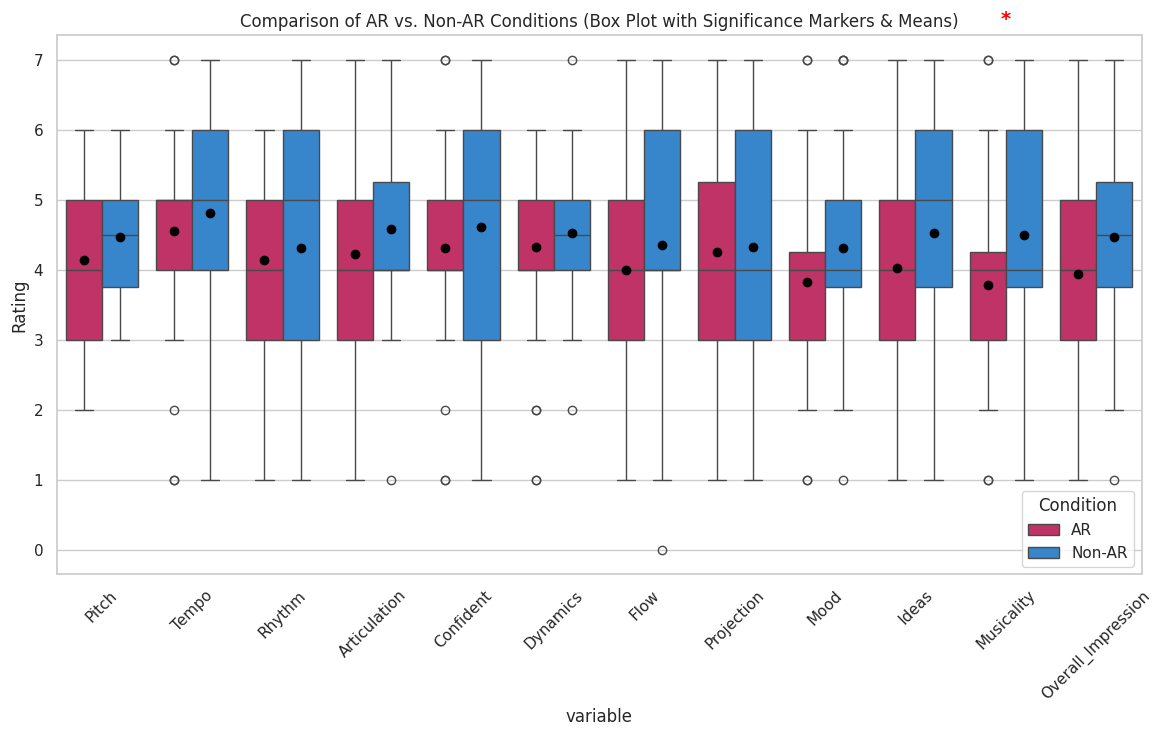

In [44]:
# Install required packages
!pip install scipy seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu

# Load dataset
file_path = "/content/pers.csv"  # Adjust path if needed
df = pd.read_csv(file_path)

# Ensure column names are stripped of leading/trailing spaces
df.columns = df.columns.str.strip()

# Convert numeric columns to float (avoiding dtype issues)
dimensions = ["Pitch", "Tempo", "Rhythm", "Articulation", "Confident",
              "Dynamics", "Flow", "Projection", "Mood", "Ideas", "Musicality", "Overall_Impression"]
df[dimensions] = df[dimensions].astype(float)

# Assign conditions: AR (odd ID) vs. Non-AR (even ID)
df["Condition"] = df["ID"].apply(lambda x: "AR" if int(x[1:]) % 2 != 0 else "Non-AR")

# Initialize result storage
stats_results = []

# Perform significance testing for each dimension
for dim in dimensions:
    ar_scores = df[df["Condition"] == "AR"][dim]
    non_ar_scores = df[df["Condition"] == "Non-AR"][dim]

    # Use t-test or Mann-Whitney U test
    _, p_ttest = ttest_ind(ar_scores, non_ar_scores, equal_var=False)
    _, p_mwu = mannwhitneyu(ar_scores, non_ar_scores, alternative="two-sided")

    # Choose p-value from the appropriate test
    p_value = p_ttest if p_ttest < 0.05 else p_mwu
    significance = "*" if p_value < 0.05 else "ns"

    # Store results
    stats_results.append((dim, p_value, significance))

# Convert results to DataFrame
results_df = pd.DataFrame(stats_results, columns=["Dimension", "p-value", "Significance"])

# Define color-blind friendly colors
color_palette = {"AR": "#D81B60", "Non-AR": "#1E88E5"}  # Red & Blue (CB-Friendly)
sns.set(style="whitegrid")

# Create box plot
plt.figure(figsize=(14, 7))
ax = sns.boxplot(data=df.melt(id_vars=["Condition"], value_vars=dimensions),
                 x="variable", y="value", hue="Condition",
                 palette=color_palette, showmeans=True,
                 meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"})

# Annotate significance markers (* for p < 0.05)
for i, row in enumerate(results_df.itertuples()):
    if row[3] == "*":  # Only mark significant differences
        plt.text(i, df[dimensions].max().max() + 0.5, row[3], ha="center", fontsize=14, color="red", fontweight="bold")

# Adjust labels and title
plt.xticks(rotation=45)
plt.legend(title="Condition")
plt.ylabel("Rating")
plt.title("Comparison of AR vs. Non-AR Conditions (Box Plot with Significance Markers & Means)")

plt.show()


im removing Sandi since there is systematic bias from his code for the var task. then we splitting the analysis for both VAR and QA tasks. Sandi is still included in the QA task analysis.

<ipython-input-45-44b56849452d>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df[dimensions] = task_df[dimensions].astype(float)


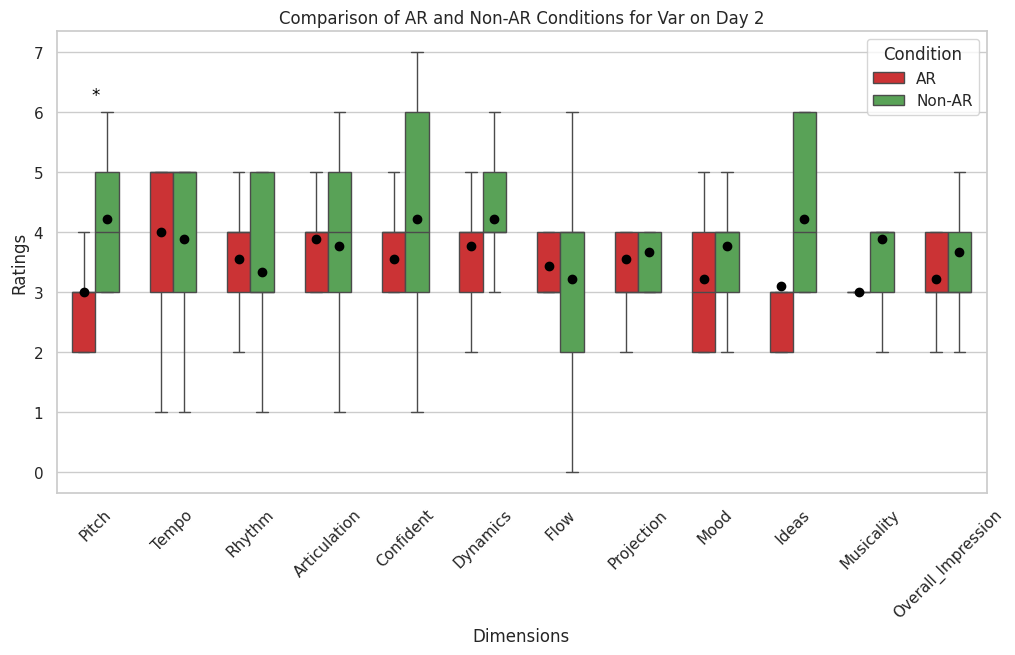

<ipython-input-45-44b56849452d>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df[dimensions] = task_df[dimensions].astype(float)


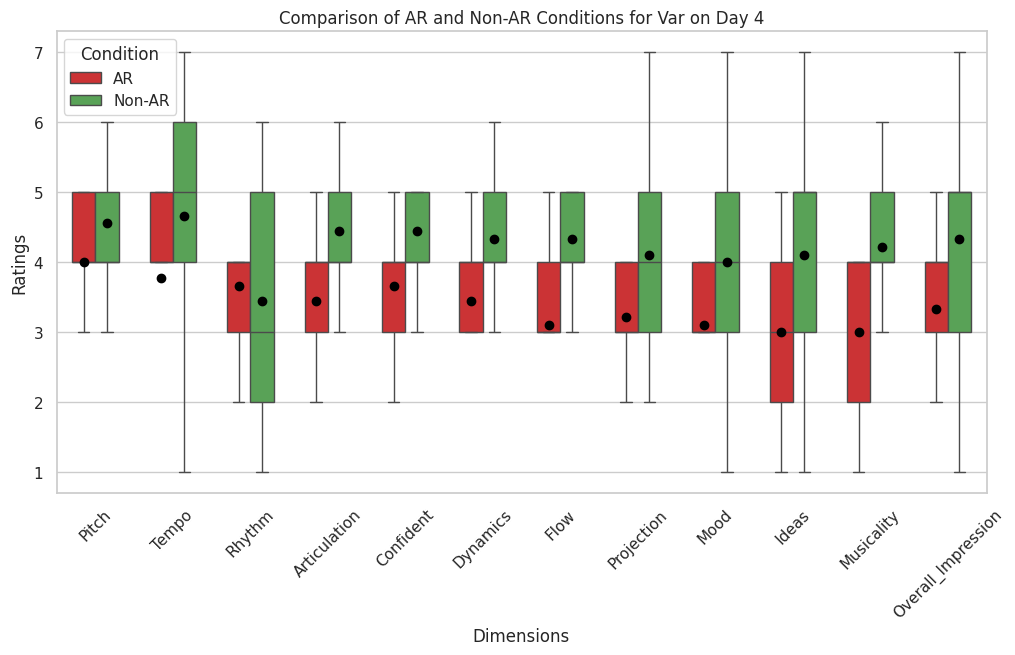

<ipython-input-45-44b56849452d>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df[dimensions] = task_df[dimensions].astype(float)


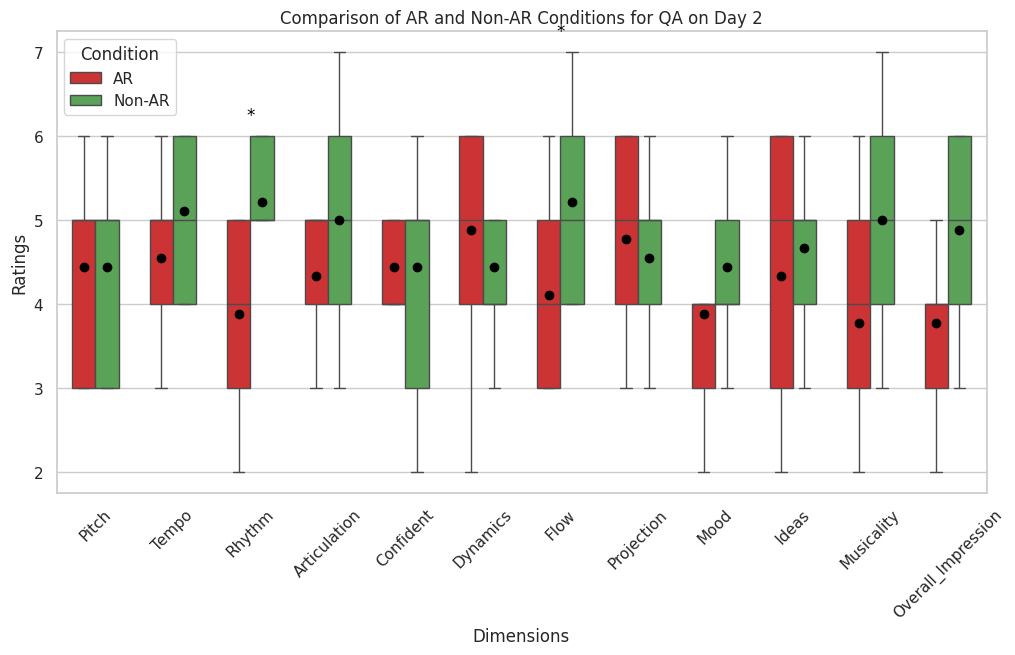

<ipython-input-45-44b56849452d>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df[dimensions] = task_df[dimensions].astype(float)


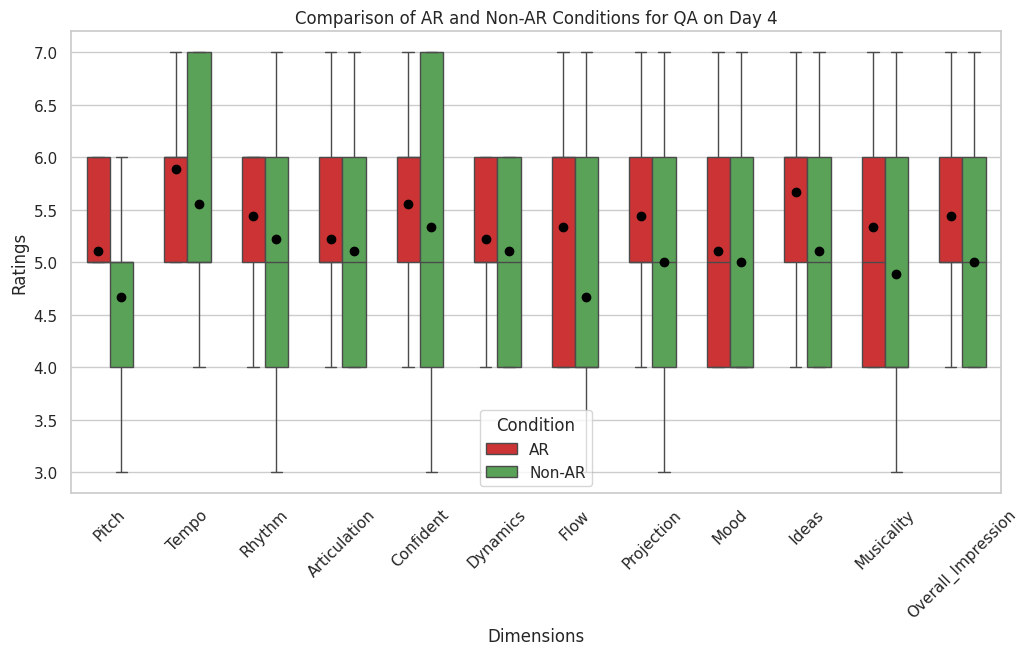

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load dataset
file_path = "/content/pers.csv"
df = pd.read_csv(file_path)

# Rename column for consistency
df.rename(columns={"Overall Impression": "Overall_Impression"}, inplace=True)

# Identify AR and non-AR participants
df["Condition"] = df["ID"].apply(lambda x: "AR" if int(x[1:]) % 2 != 0 else "Non-AR")

# Define significance levels
significance_levels = {0.001: "***", 0.01: "**", 0.05: "*"}

# Function to perform t-tests and generate plots
def analyze_task(df, task_name, day):
    task_df = df[(df["Task"] == task_name) & (df["Day"] == day)]

    dimensions = [col for col in df.columns if col not in ["ID", "Task", "Day", "Condition", "Rater"]]
    task_df[dimensions] = task_df[dimensions].astype(float)

    # Initialize dictionary to store p-values
    p_values = {}

    # Perform statistical tests
    for dimension in dimensions:
        ar_values = task_df[task_df["Condition"] == "AR"][dimension]
        non_ar_values = task_df[task_df["Condition"] == "Non-AR"][dimension]
        t_stat, p_val = stats.ttest_ind(ar_values, non_ar_values, nan_policy='omit')
        p_values[dimension] = p_val

    # Generate Box Plots
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    ax = sns.boxplot(
        data=task_df.melt(id_vars=["Condition"], value_vars=dimensions),
        x="variable", y="value", hue="Condition",
        palette={"AR": "#E41A1C", "Non-AR": "#4DAF4A"},  # Colorblind-friendly red & green
        showfliers=False,  # Remove outliers
        width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        showmeans=True
    )

    # Annotate significant differences
    for i, dimension in enumerate(dimensions):
        p_val = p_values[dimension]
        sig_marker = next((mark for threshold, mark in significance_levels.items() if p_val < threshold), "")
        if sig_marker:
            x_pos = i
            y_max = task_df[dimension].max()
            plt.text(x_pos, y_max + 0.2, sig_marker, ha='center', fontsize=12, color='black')

    plt.xlabel("Dimensions")
    plt.ylabel("Ratings")
    plt.title(f"Comparison of AR and Non-AR Conditions for {task_name} on Day {day}")
    plt.legend(title="Condition")
    plt.xticks(rotation=45)
    plt.show()

# Analyze VAR and QA tasks separately for Day 2 and Day 4
analyze_task(df, "Var", day=2)
analyze_task(df, "Var", day=4)
analyze_task(df, "QA", day=2)
analyze_task(df, "QA", day=4)


here's the averages data set instead.

<ipython-input-46-3ba4410efa30>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df[dimensions] = task_df[dimensions].astype(float)
/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


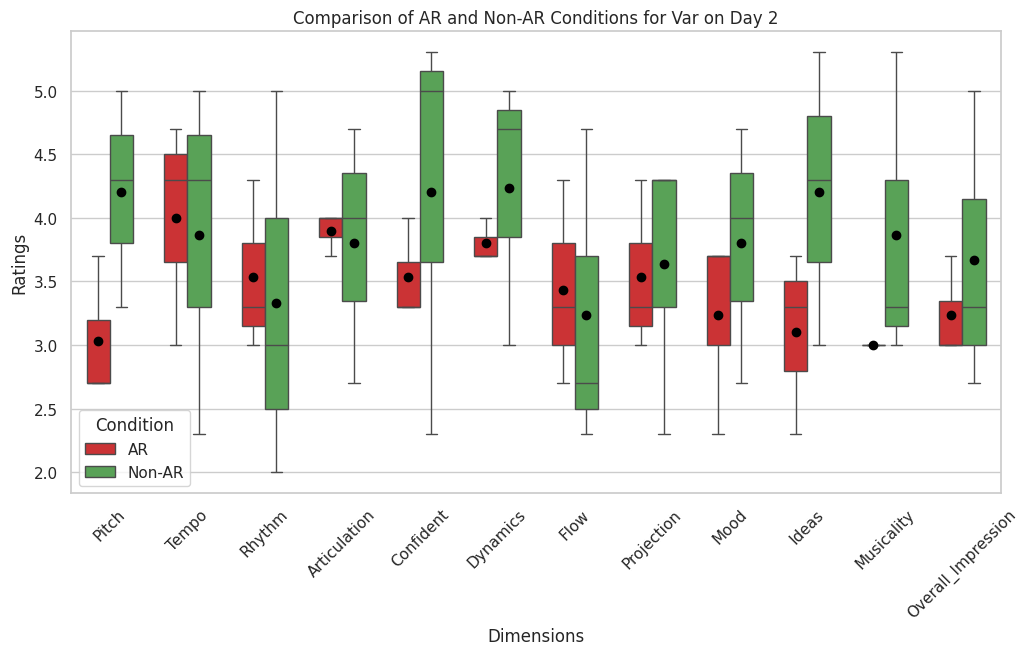

<ipython-input-46-3ba4410efa30>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df[dimensions] = task_df[dimensions].astype(float)


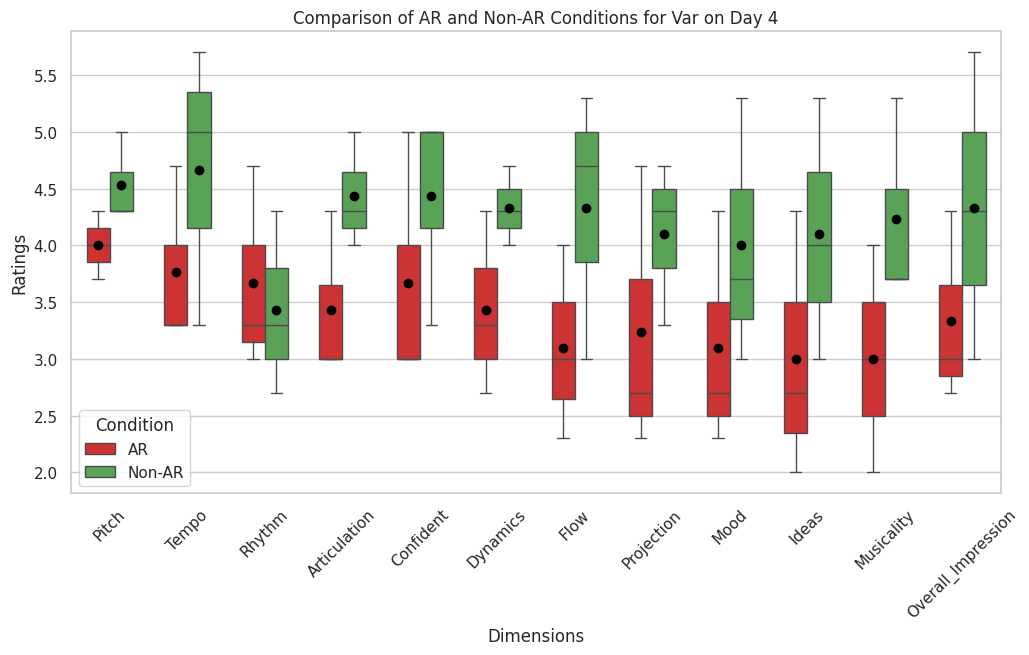

<ipython-input-46-3ba4410efa30>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df[dimensions] = task_df[dimensions].astype(float)


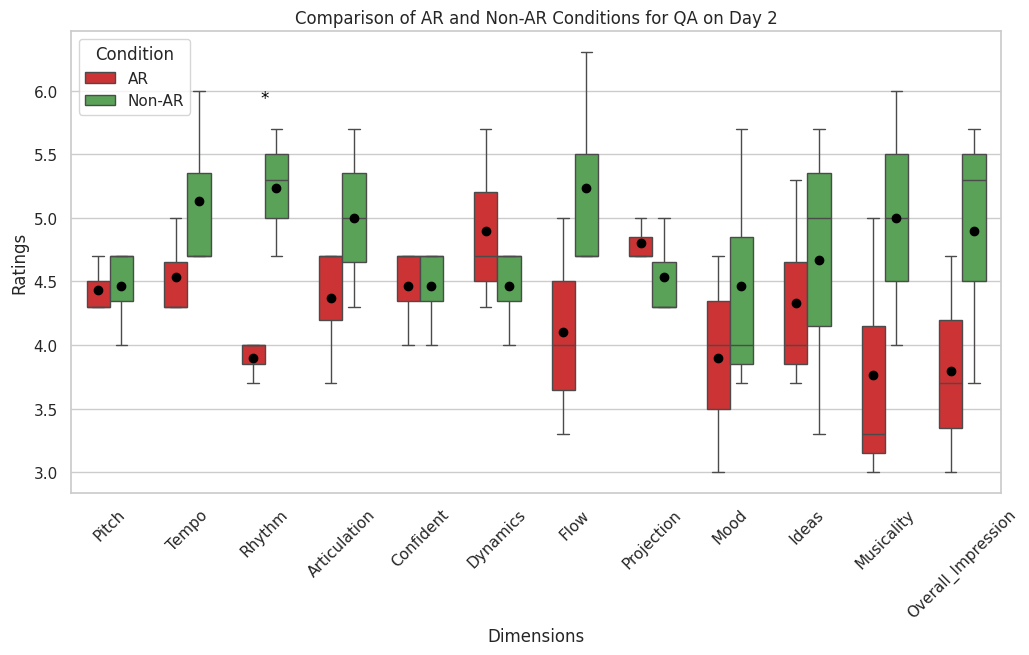

<ipython-input-46-3ba4410efa30>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_df[dimensions] = task_df[dimensions].astype(float)


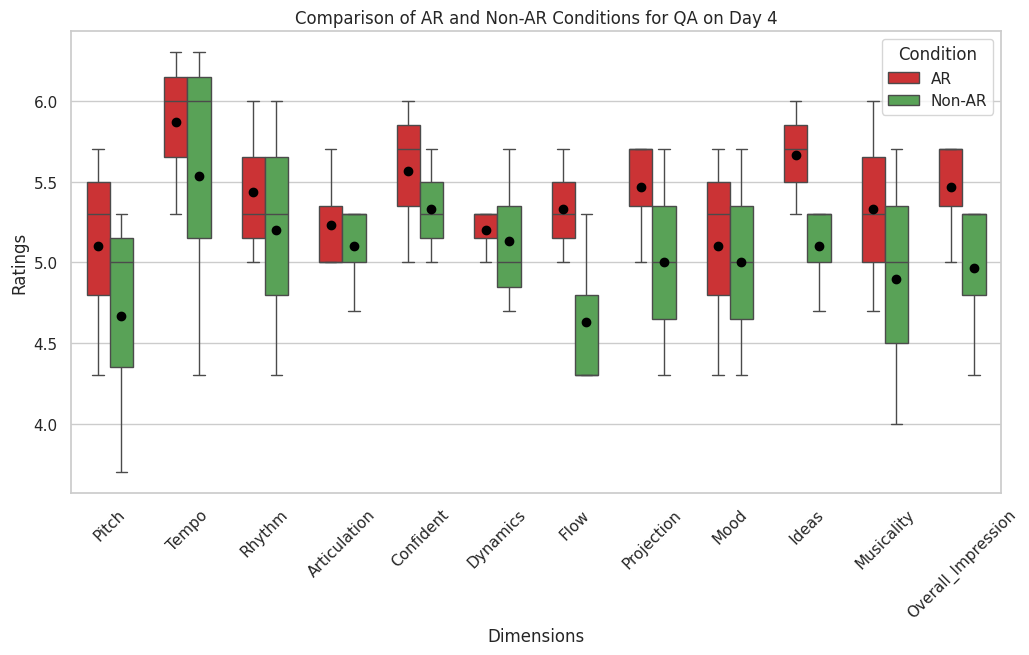

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load dataset with comma separator
file_path = "/content/pers2.csv"
df = pd.read_csv(file_path, sep="\t")

# Rename column for consistency
df.rename(columns={"Overall Impression": "Overall_Impression"}, inplace=True)

# Identify AR and non-AR participants
df["Condition"] = df["ID"].apply(lambda x: "AR" if int(x[1:]) % 2 != 0 else "Non-AR")

# Define significance levels
significance_levels = {0.001: "***", 0.01: "**", 0.05: "*"}

# Function to perform t-tests and generate plots
def analyze_task(df, task_name, day):
    task_df = df[(df["Task"] == task_name) & (df["Day"] == day)]

    dimensions = [col for col in df.columns if col not in ["ID", "Task", "Day", "Condition", "Rater"]]
    task_df[dimensions] = task_df[dimensions].astype(float)

    # Initialize dictionary to store p-values
    p_values = {}

    # Perform statistical tests
    for dimension in dimensions:
        ar_values = task_df[task_df["Condition"] == "AR"][dimension]
        non_ar_values = task_df[task_df["Condition"] == "Non-AR"][dimension]
        t_stat, p_val = stats.ttest_ind(ar_values, non_ar_values, nan_policy='omit')
        p_values[dimension] = p_val

    # Generate Box Plots
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    ax = sns.boxplot(
        data=task_df.melt(id_vars=["Condition"], value_vars=dimensions),
        x="variable", y="value", hue="Condition",
        palette={"AR": "#E41A1C", "Non-AR": "#4DAF4A"},  # Colorblind-friendly red & green
        showfliers=False,  # Remove outliers
        width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        showmeans=True
    )

    # Annotate significant differences
    for i, dimension in enumerate(dimensions):
        p_val = p_values[dimension]
        sig_marker = next((mark for threshold, mark in significance_levels.items() if p_val < threshold), "")
        if sig_marker:
            x_pos = i
            y_max = task_df[dimension].max()
            plt.text(x_pos, y_max + 0.2, sig_marker, ha='center', fontsize=12, color='black')

    plt.xlabel("Dimensions")
    plt.ylabel("Ratings")
    plt.title(f"Comparison of AR and Non-AR Conditions for {task_name} on Day {day}")
    plt.legend(title="Condition")
    plt.xticks(rotation=45)
    plt.show()

# Analyze VAR and QA tasks separately for Day 2 and Day 4
analyze_task(df, "Var", day=2)
analyze_task(df, "Var", day=4)
analyze_task(df, "QA", day=2)
analyze_task(df, "QA", day=4)


now lets see if theres a signficant difference in the change of ratings from day 2 to day 4 for each dimension for each task.

<ipython-input-47-706aac5215a6>:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


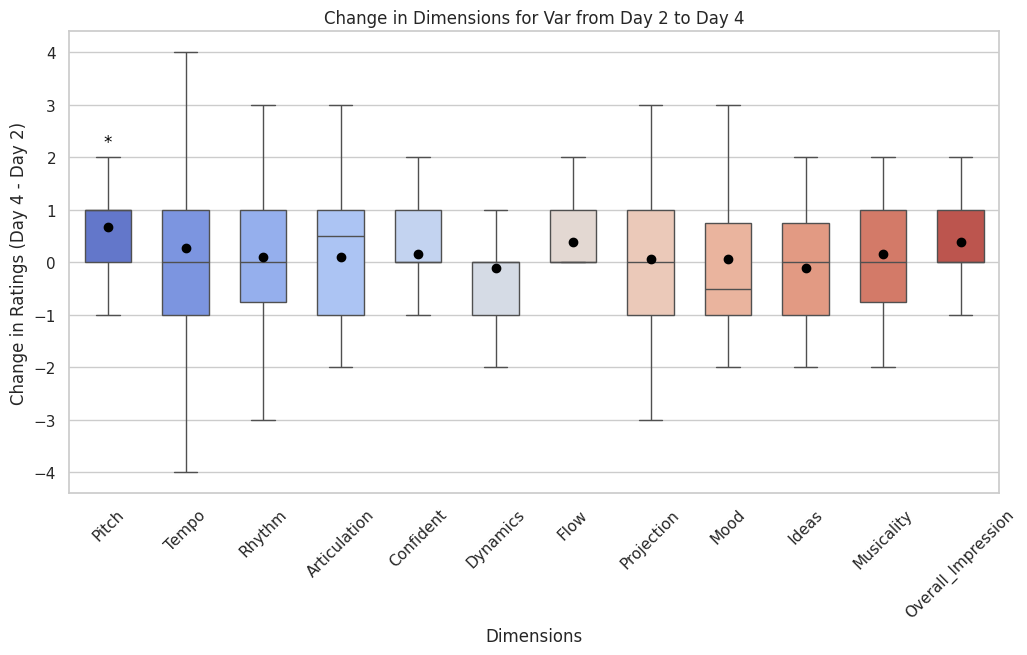

<ipython-input-47-706aac5215a6>:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


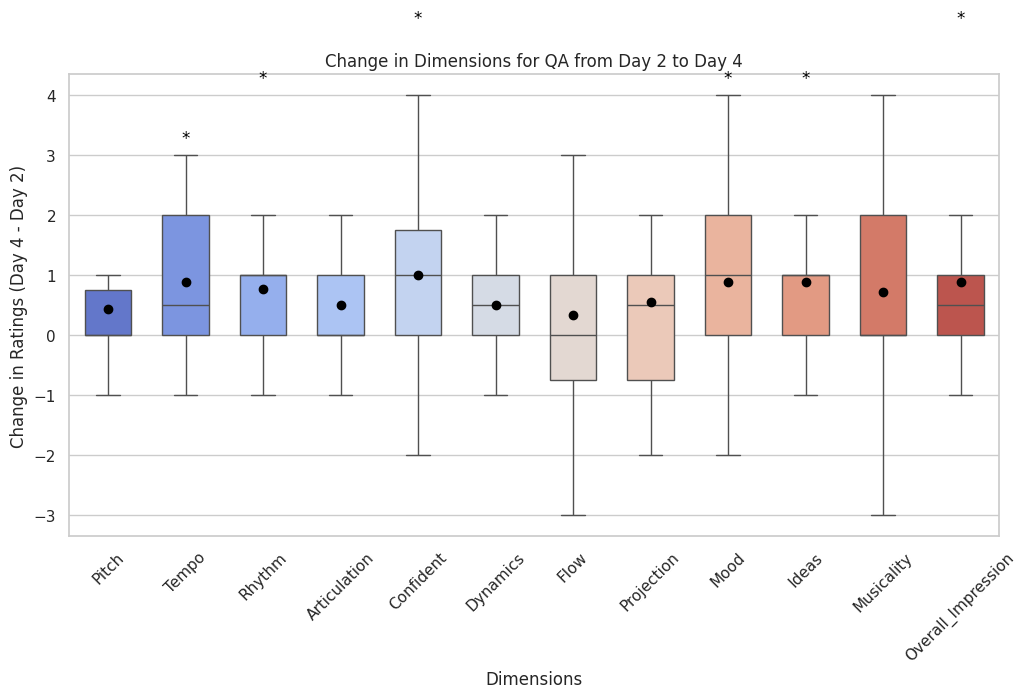

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load dataset with comma separator
file_path = "/content/pers.csv"
df = pd.read_csv(file_path, sep=",")

# Rename column for consistency
df.rename(columns={"Overall Impression": "Overall_Impression"}, inplace=True)

# Identify AR and non-AR participants
df["Condition"] = df["ID"].apply(lambda x: "AR" if int(x[1:]) % 2 != 0 else "Non-AR")

# Define significance levels
significance_levels = {0.001: "***", 0.01: "**", 0.05: "*"}

# Function to analyze change from Day 2 to Day 4 per task
def analyze_change(df, task_name):
    day2_df = df[(df["Task"] == task_name) & (df["Day"] == 2)].set_index("ID")
    day4_df = df[(df["Task"] == task_name) & (df["Day"] == 4)].set_index("ID")

    common_ids = day2_df.index.intersection(day4_df.index)
    day2_df = day2_df.loc[common_ids]
    day4_df = day4_df.loc[common_ids]

    dimensions = [col for col in df.columns if col not in ["ID", "Task", "Day", "Condition", "Rater"]]
    changes = day4_df[dimensions] - day2_df[dimensions]

    # Perform paired t-tests
    p_values = {}
    for dimension in dimensions:
        t_stat, p_val = stats.ttest_rel(day2_df[dimension], day4_df[dimension], nan_policy='omit')
        p_values[dimension] = p_val

    # Generate Box Plots of Change
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    ax = sns.boxplot(
        data=changes.melt(var_name="Dimension", value_name="Change"),
        x="Dimension", y="Change",
        palette="coolwarm",
        showfliers=False, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        showmeans=True
    )

    # Annotate significant differences
    for i, dimension in enumerate(dimensions):
        p_val = p_values[dimension]
        sig_marker = next((mark for threshold, mark in significance_levels.items() if p_val < threshold), "")
        if sig_marker:
            x_pos = i
            y_max = changes[dimension].max()
            plt.text(x_pos, y_max + 0.2, sig_marker, ha='center', fontsize=12, color='black')

    plt.xlabel("Dimensions")
    plt.ylabel("Change in Ratings (Day 4 - Day 2)")
    plt.title(f"Change in Dimensions for {task_name} from Day 2 to Day 4")
    plt.xticks(rotation=45)
    plt.show()

# Analyze changes for VAR and QA tasks
analyze_change(df, "Var")
analyze_change(df, "QA")


showing lines per dimension

<ipython-input-48-706aac5215a6>:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


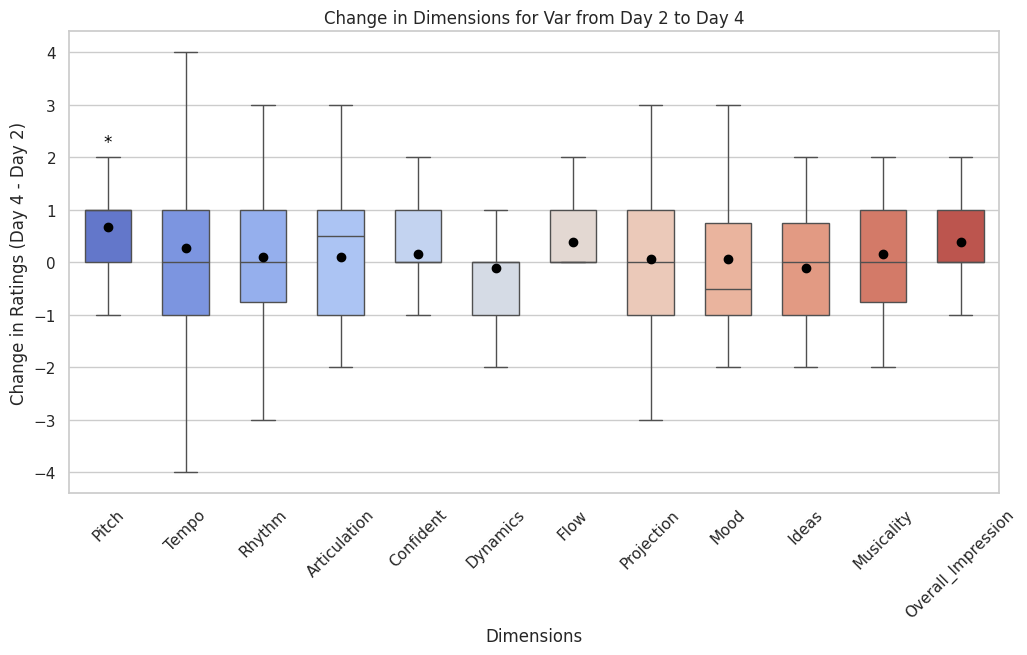

<ipython-input-48-706aac5215a6>:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


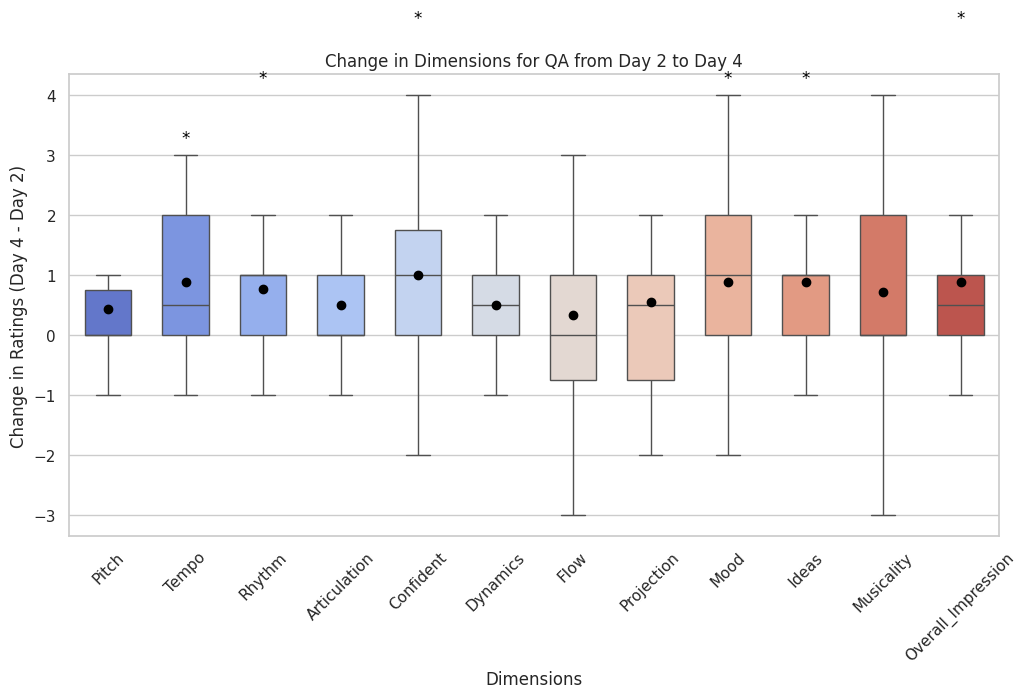

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load dataset with comma separator
file_path = "/content/pers.csv"
df = pd.read_csv(file_path, sep=",")

# Rename column for consistency
df.rename(columns={"Overall Impression": "Overall_Impression"}, inplace=True)

# Identify AR and non-AR participants
df["Condition"] = df["ID"].apply(lambda x: "AR" if int(x[1:]) % 2 != 0 else "Non-AR")

# Define significance levels
significance_levels = {0.001: "***", 0.01: "**", 0.05: "*"}

# Function to analyze change from Day 2 to Day 4 per task
def analyze_change(df, task_name):
    day2_df = df[(df["Task"] == task_name) & (df["Day"] == 2)].set_index("ID")
    day4_df = df[(df["Task"] == task_name) & (df["Day"] == 4)].set_index("ID")

    common_ids = day2_df.index.intersection(day4_df.index)
    day2_df = day2_df.loc[common_ids]
    day4_df = day4_df.loc[common_ids]

    dimensions = [col for col in df.columns if col not in ["ID", "Task", "Day", "Condition", "Rater"]]
    changes = day4_df[dimensions] - day2_df[dimensions]

    # Perform paired t-tests
    p_values = {}
    for dimension in dimensions:
        t_stat, p_val = stats.ttest_rel(day2_df[dimension], day4_df[dimension], nan_policy='omit')
        p_values[dimension] = p_val

    # Generate Box Plots of Change
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    ax = sns.boxplot(
        data=changes.melt(var_name="Dimension", value_name="Change"),
        x="Dimension", y="Change",
        palette="coolwarm",
        showfliers=False, width=0.6,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        showmeans=True
    )

    # Annotate significant differences
    for i, dimension in enumerate(dimensions):
        p_val = p_values[dimension]
        sig_marker = next((mark for threshold, mark in significance_levels.items() if p_val < threshold), "")
        if sig_marker:
            x_pos = i
            y_max = changes[dimension].max()
            plt.text(x_pos, y_max + 0.2, sig_marker, ha='center', fontsize=12, color='black')

    plt.xlabel("Dimensions")
    plt.ylabel("Change in Ratings (Day 4 - Day 2)")
    plt.title(f"Change in Dimensions for {task_name} from Day 2 to Day 4")
    plt.xticks(rotation=45)
    plt.show()

# Analyze changes for VAR and QA tasks
analyze_change(df, "Var")
analyze_change(df, "QA")


doing now a per condition analysis of the changes in dimensions

<ipython-input-49-d886bc9ae6de>:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot([x[i] - offset, x[i] + offset], [means_day2[i], means_day4[i]],
<ipython-input-49-d886bc9ae6de>:74: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_max = max(means_day2[i], means_day4[i])


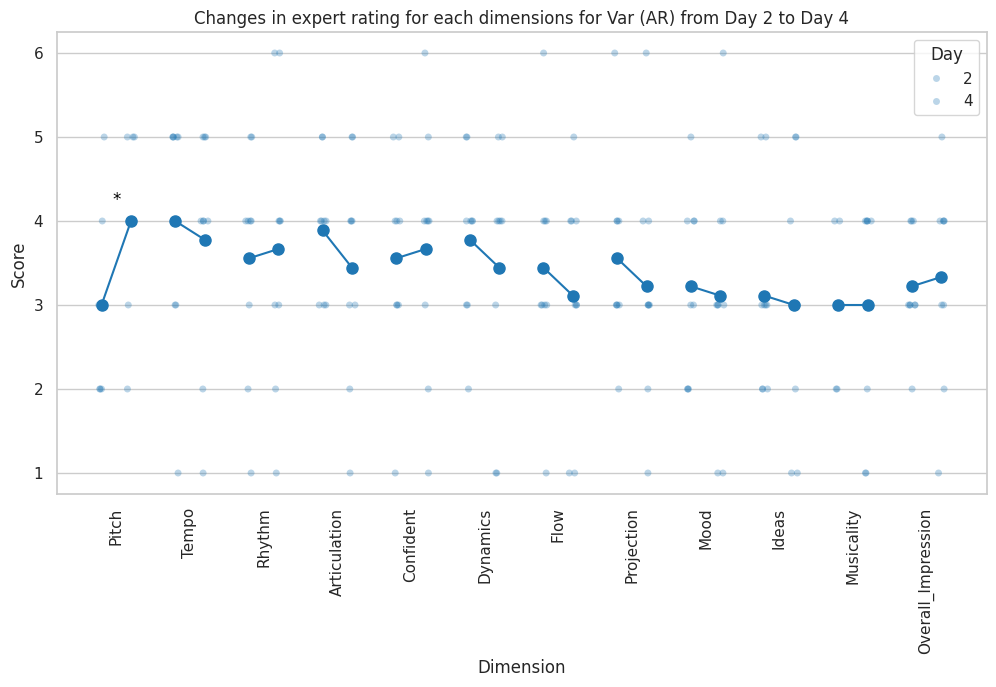

<ipython-input-49-d886bc9ae6de>:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot([x[i] - offset, x[i] + offset], [means_day2[i], means_day4[i]],


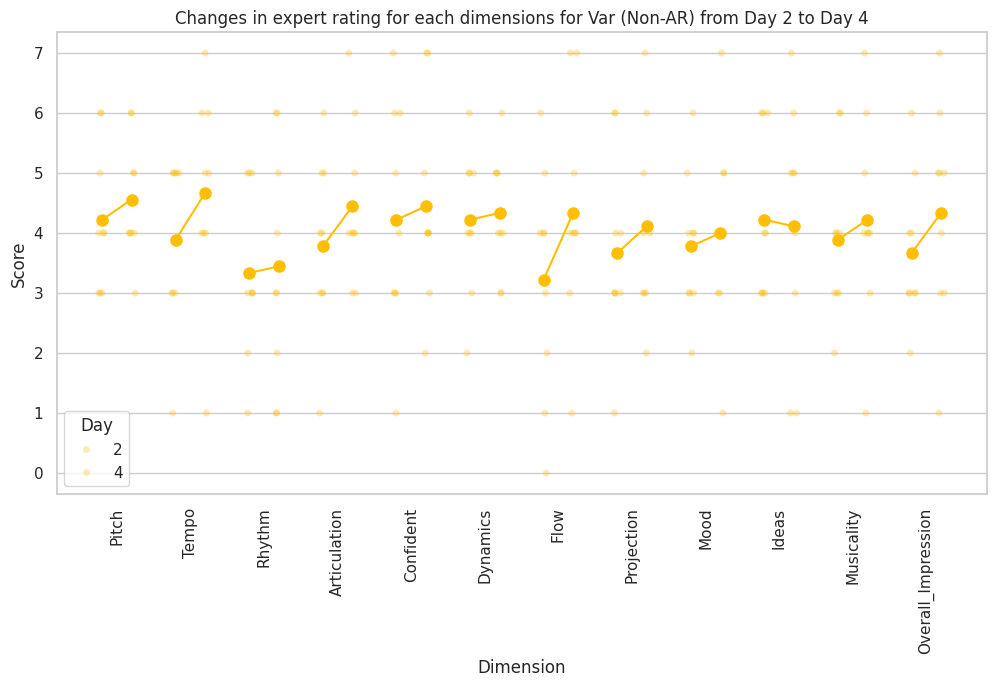

<ipython-input-49-d886bc9ae6de>:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot([x[i] - offset, x[i] + offset], [means_day2[i], means_day4[i]],
<ipython-input-49-d886bc9ae6de>:74: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_max = max(means_day2[i], means_day4[i])


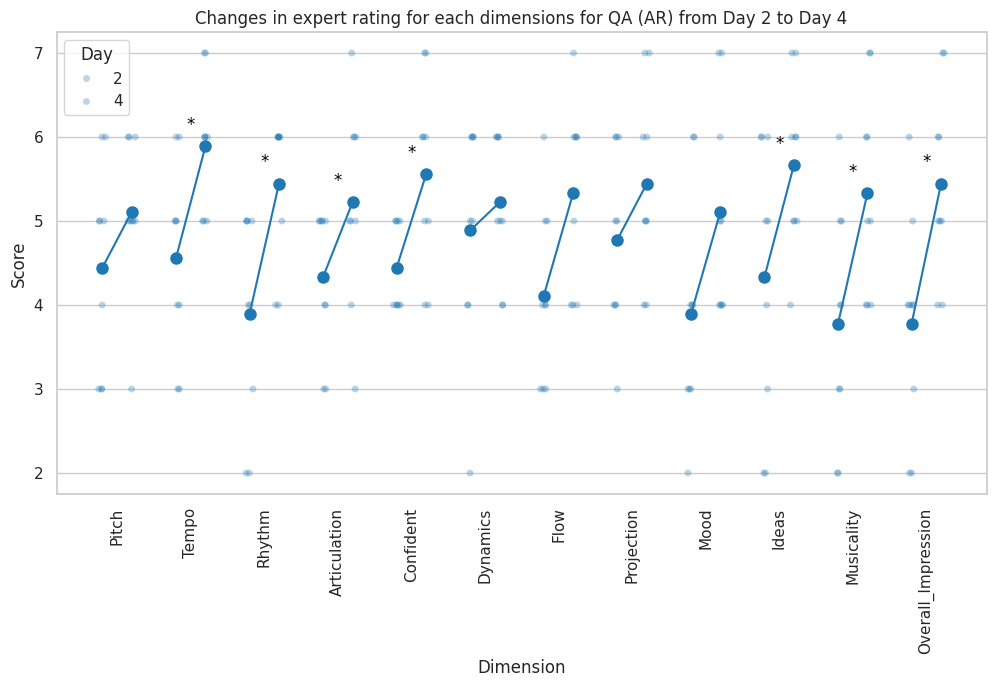

<ipython-input-49-d886bc9ae6de>:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot([x[i] - offset, x[i] + offset], [means_day2[i], means_day4[i]],


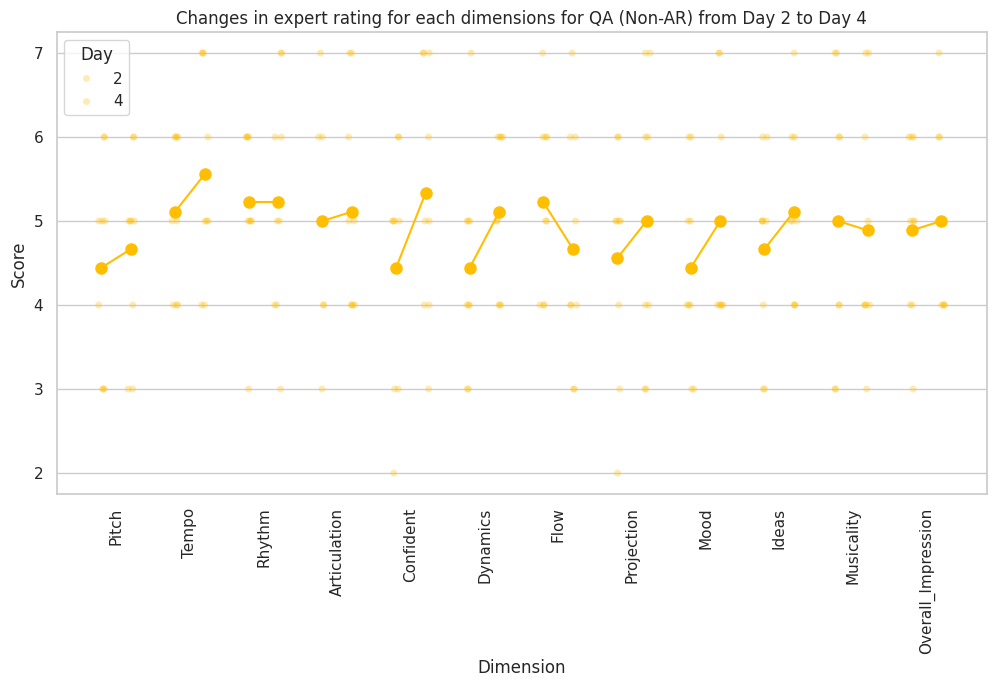

In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load dataset with comma separator
file_path = "/content/pers.csv"
df = pd.read_csv(file_path, sep=",")

# Rename column for consistency
df.rename(columns={"Overall Impression": "Overall_Impression"}, inplace=True)

# Identify AR and non-AR participants
df["Condition"] = df["ID"].apply(lambda x: "AR" if int(x[1:]) % 2 != 0 else "Non-AR")

# Define significance levels
significance_levels = {0.001: "***", 0.01: "**", 0.05: "*"}

# Function to analyze change per task and condition
def analyze_change(df, task_name, condition_name):
    task_df = df[(df["Task"] == task_name) & (df["Condition"] == condition_name)]
    day2_df = task_df[task_df["Day"] == 2].set_index("ID")
    day4_df = task_df[task_df["Day"] == 4].set_index("ID")

    common_ids = day2_df.index.intersection(day4_df.index)
    day2_df = day2_df.loc[common_ids]
    day4_df = day4_df.loc[common_ids]

    dimensions = [col for col in df.columns if col not in ["ID", "Task", "Day", "Condition", "Rater"]]

    # Compute means and quartiles
    means_day2 = day2_df[dimensions].mean()
    means_day4 = day4_df[dimensions].mean()
    q1_day2 = day2_df[dimensions].quantile(0.25)
    q3_day2 = day2_df[dimensions].quantile(0.75)
    q1_day4 = day4_df[dimensions].quantile(0.25)
    q3_day4 = day4_df[dimensions].quantile(0.75)

    # Perform paired t-tests
    p_values = {}
    for dimension in dimensions:
        t_stat, p_val = stats.ttest_rel(day2_df[dimension], day4_df[dimension], nan_policy='omit')
        p_values[dimension] = p_val

    # Create a plot
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    x = np.arange(len(dimensions))  # X-axis positions
    offset = 0.2  # Small offset to separate Day 2 and Day 4 markers
    colors = {"AR": "#1f77b4", "Non-AR": "#ffbf00"}  # Blue for AR, Gold for Non-AR

    # Scatter plots with reduced opacity
    data_melted = task_df.melt(id_vars=["ID", "Day"], value_vars=dimensions, var_name="Dimension", value_name="Score")
    sns.stripplot(x="Dimension", y="Score", hue="Day", data=data_melted,
                  palette={2: colors[condition_name], 4: colors[condition_name]},
                  dodge=True, alpha=0.3, jitter=True)

    # Plot quartile lines instead of thick box plots
    for i in range(len(dimensions)):
        #plt.plot([x[i] - offset, x[i] - offset], [q1_day2[i], q3_day2[i]], color=colors[condition_name], linewidth=2)
        #plt.plot([x[i] + offset, x[i] + offset], [q1_day4[i], q3_day4[i]], color=colors[condition_name], linewidth=2)

        # Add mean connection lines (solid line now)
        plt.plot([x[i] - offset, x[i] + offset], [means_day2[i], means_day4[i]],
                 color=colors[condition_name], linestyle="-", marker="o", markersize=8)

    # Annotate significance
    for i, dimension in enumerate(dimensions):
        p_val = p_values[dimension]
        sig_marker = next((mark for threshold, mark in significance_levels.items() if p_val < threshold), "")
        if sig_marker:
            y_max = max(means_day2[i], means_day4[i])
            plt.text(x[i], y_max + 0.2, sig_marker, ha='center', fontsize=12, color='black')

    plt.xticks(x, dimensions, rotation=90)
    plt.ylabel("Score")
    plt.title(f"Changes in expert rating for each dimensions for {task_name} ({condition_name}) from Day 2 to Day 4")
    plt.legend(title="Day")
    plt.show()

# Generate plots per task and per condition
for task in ["Var", "QA"]:
    for condition in ["AR", "Non-AR"]:
        analyze_change(df, task, condition)


now we overlap them

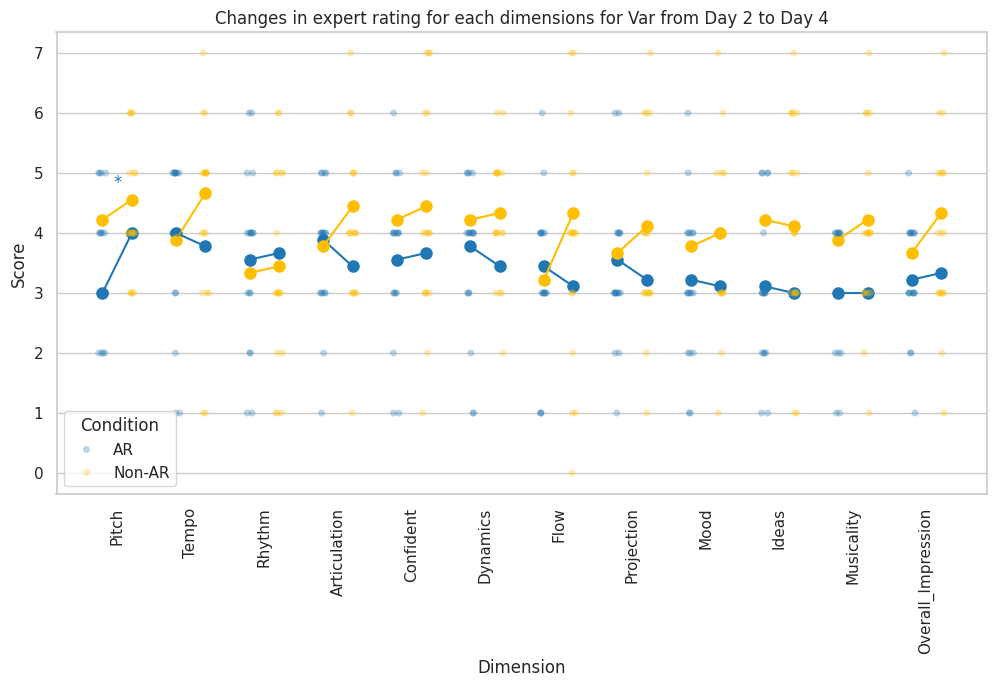

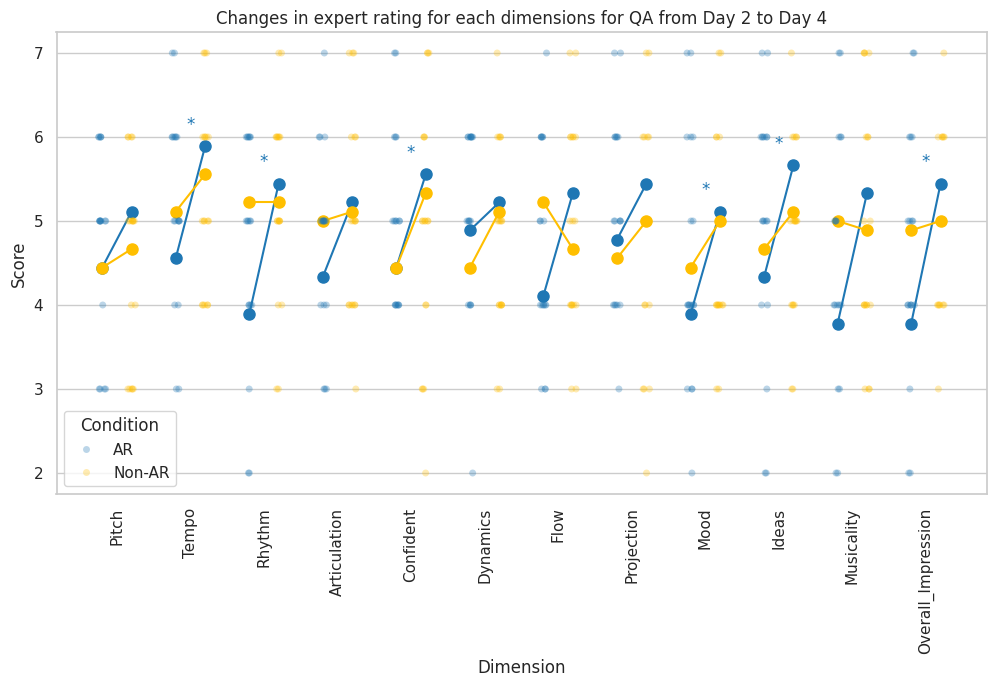

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load dataset with comma separator
file_path = "/content/pers.csv"
df = pd.read_csv(file_path, sep=",")

# Rename column for consistency
df.rename(columns={"Overall Impression": "Overall_Impression"}, inplace=True)

# Identify AR and non-AR participants
df["Condition"] = df["ID"].apply(lambda x: "AR" if int(x[1:]) % 2 != 0 else "Non-AR")

# Define significance levels
significance_levels = {0.001: "***", 0.01: "**", 0.05: "*"}

# Function to analyze change per task and condition
def analyze_change(df, task_name):
    task_df = df[df["Task"] == task_name]
    day2_df = task_df[task_df["Day"] == 2].set_index("ID")
    day4_df = task_df[task_df["Day"] == 4].set_index("ID")

    common_ids = day2_df.index.intersection(day4_df.index)
    day2_df = day2_df.loc[common_ids]
    day4_df = day4_df.loc[common_ids]

    dimensions = [col for col in df.columns if col not in ["ID", "Task", "Day", "Condition", "Rater"]]

    # Compute means and quartiles
    means_day2 = day2_df.groupby("Condition")[dimensions].mean()
    means_day4 = day4_df.groupby("Condition")[dimensions].mean()
    q1_day2 = day2_df.groupby("Condition")[dimensions].quantile(0.25)
    q3_day2 = day2_df.groupby("Condition")[dimensions].quantile(0.75)
    q1_day4 = day4_df.groupby("Condition")[dimensions].quantile(0.25)
    q3_day4 = day4_df.groupby("Condition")[dimensions].quantile(0.75)

    # Perform paired t-tests
    p_values = {dim: stats.ttest_rel(day2_df[dim], day4_df[dim], nan_policy='omit').pvalue for dim in dimensions}

    # Create a plot
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    x = np.arange(len(dimensions))
    offset = 0.2
    colors = {"AR": "#1f77b4", "Non-AR": "#ffbf00"}  # Blue for AR, Gold for Non-AR

    # Scatter plots with reduced opacity
    data_melted = task_df.melt(id_vars=["ID", "Day", "Condition"], value_vars=dimensions, var_name="Dimension", value_name="Score")
    sns.stripplot(x="Dimension", y="Score", hue="Condition", data=data_melted,
                  palette=colors, dodge=True, alpha=0.3, jitter=True)

    # Plot quartile lines and mean connection lines
    for condition in ["AR", "Non-AR"]:
        for i in range(len(dimensions)):
           # plt.plot([x[i] - offset, x[i] - offset], [q1_day2.loc[condition, dimensions[i]], q3_day2.loc[condition, dimensions[i]]], color=colors[condition], linewidth=2)
            #plt.plot([x[i] + offset, x[i] + offset], [q1_day4.loc[condition, dimensions[i]], q3_day4.loc[condition, dimensions[i]]], color=colors[condition], linewidth=2)
            plt.plot([x[i] - offset, x[i] + offset], [means_day2.loc[condition, dimensions[i]], means_day4.loc[condition, dimensions[i]]],
                     color=colors[condition], linestyle="-", marker="o", markersize=8)

    # Annotate significance with condition-specific colors
    for i, dimension in enumerate(dimensions):
        sig_marker = next((mark for threshold, mark in significance_levels.items() if p_values[dimension] < threshold), "")
        if sig_marker:
            y_max = max(means_day2[dimension].max(), means_day4[dimension].max())
            significant_condition = "AR" if means_day4.loc["AR", dimension] - means_day2.loc["AR", dimension] != 0 else "Non-AR"
            plt.text(x[i], y_max + 0.2, sig_marker, ha='center', fontsize=12, color=colors[significant_condition])

    plt.xticks(x, dimensions, rotation=90)
    plt.ylabel("Score")
    plt.title(f"Changes in expert rating for each dimensions for {task_name} from Day 2 to Day 4")
    plt.legend(title="Condition")
    plt.show()

# Generate plots per task
for task in ["Var", "QA"]:
    analyze_change(df, task)


okay we removing the scatter plots

<ipython-input-51-41372781e1c5>:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Condition")


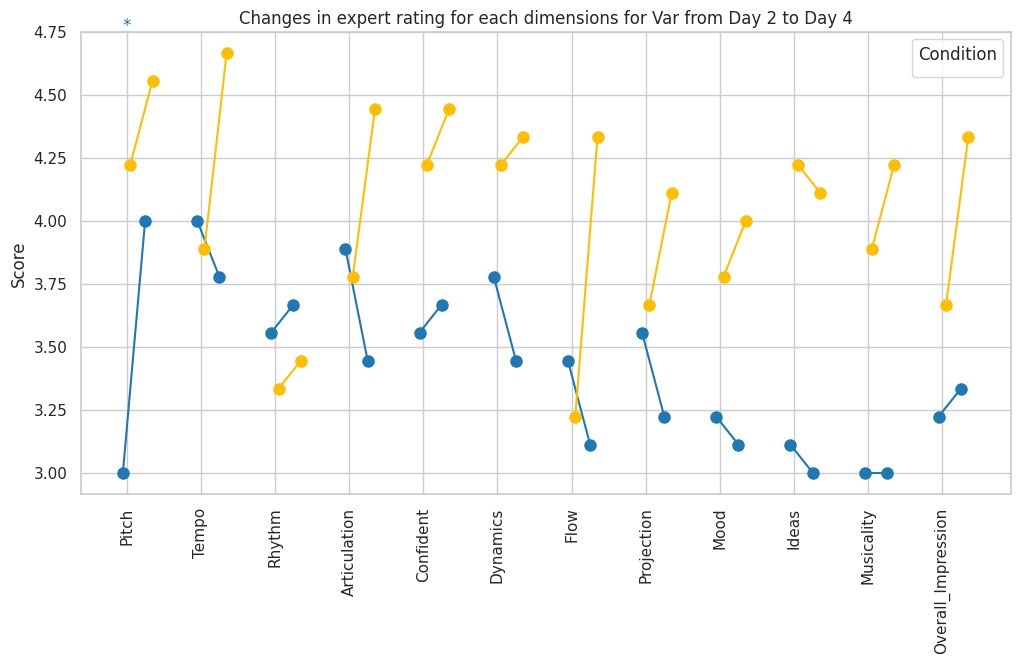

<ipython-input-51-41372781e1c5>:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Condition")


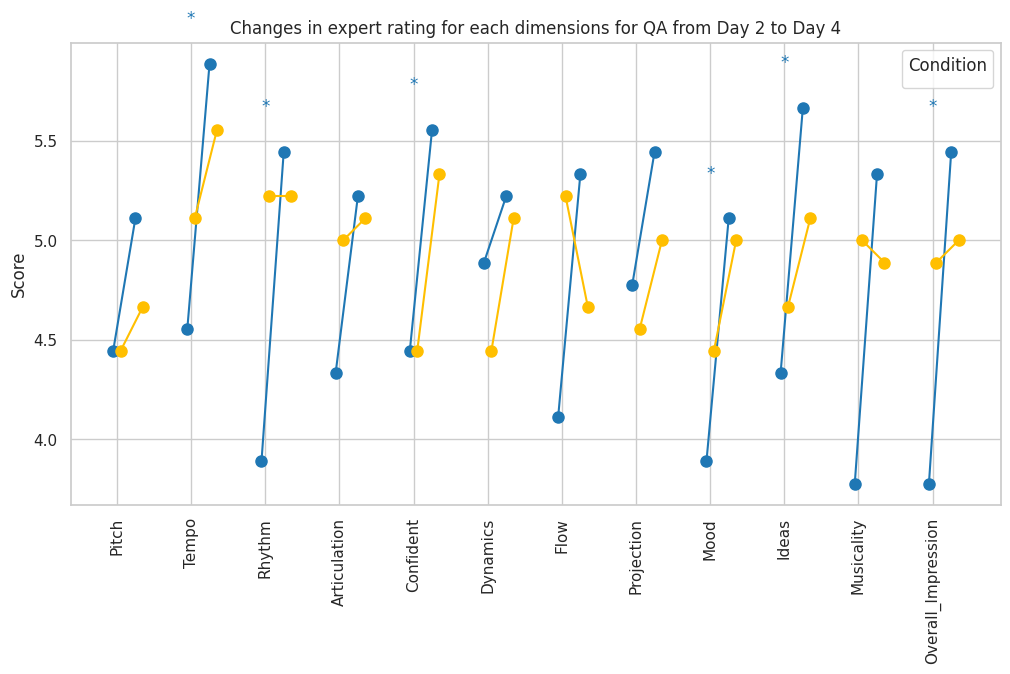

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load dataset with comma separator
file_path = "/content/pers.csv"
df = pd.read_csv(file_path, sep=",")

# Rename column for consistency
df.rename(columns={"Overall Impression": "Overall_Impression"}, inplace=True)

# Identify AR and non-AR participants
df["Condition"] = df["ID"].apply(lambda x: "AR" if int(x[1:]) % 2 != 0 else "Non-AR")

# Define significance levels
significance_levels = {0.001: "***", 0.01: "**", 0.05: "*"}

# Function to analyze change per task and condition
def analyze_change(df, task_name):
    task_df = df[df["Task"] == task_name]
    day2_df = task_df[task_df["Day"] == 2].set_index("ID")
    day4_df = task_df[task_df["Day"] == 4].set_index("ID")

    common_ids = day2_df.index.intersection(day4_df.index)
    day2_df = day2_df.loc[common_ids]
    day4_df = day4_df.loc[common_ids]

    dimensions = [col for col in df.columns if col not in ["ID", "Task", "Day", "Condition", "Rater"]]

    # Compute means and quartiles
    means_day2 = day2_df.groupby("Condition")[dimensions].mean()
    means_day4 = day4_df.groupby("Condition")[dimensions].mean()
    q1_day2 = day2_df.groupby("Condition")[dimensions].quantile(0.25)
    q3_day2 = day2_df.groupby("Condition")[dimensions].quantile(0.75)
    q1_day4 = day4_df.groupby("Condition")[dimensions].quantile(0.25)
    q3_day4 = day4_df.groupby("Condition")[dimensions].quantile(0.75)

    # Perform paired t-tests
    p_values = {dim: stats.ttest_rel(day2_df[dim], day4_df[dim], nan_policy='omit').pvalue for dim in dimensions}

    # Create a plot
    plt.figure(figsize=(12, 6)) #changed to 14 revert to 12 if fcked up
    sns.set_style("whitegrid")

    x = np.arange(len(dimensions))
    offset_ar = -0.05  # Slightly to the left originally -0.05
    offset_non_ar = 0.05  # Slightly to the right originally 0.05
    colors = {"AR": "#1f77b4", "Non-AR": "#ffbf00"}  # Blue for AR, Gold for Non-AR

    # Plot quartile lines and mean connection lines
    for condition, offset in zip(["AR", "Non-AR"], [offset_ar, offset_non_ar]):
        for i in range(len(dimensions)): #just uncomment the two lines below if you wanna return the quartile lines
           # plt.plot([x[i] + offset, x[i] + offset], [q1_day2.loc[condition, dimensions[i]], q3_day2.loc[condition, dimensions[i]]], color=colors[condition], linewidth=2)
            #plt.plot([x[i] + offset + 0.1, x[i] + offset + 0.3], [q1_day4.loc[condition, dimensions[i]], q3_day4.loc[condition, dimensions[i]]], color=colors[condition], linewidth=2)
            plt.plot([x[i] + offset, x[i] + offset + 0.3], [means_day2.loc[condition, dimensions[i]], means_day4.loc[condition, dimensions[i]]],
                     color=colors[condition], linestyle="-", marker="o", markersize=8)

    # Annotate significance with condition-specific colors
    for i, dimension in enumerate(dimensions):
        sig_marker = next((mark for threshold, mark in significance_levels.items() if p_values[dimension] < threshold), "")
        if sig_marker:
            y_max = max(means_day2[dimension].max(), means_day4[dimension].max())
            significant_condition = "AR" if means_day4.loc["AR", dimension] - means_day2.loc["AR", dimension] != 0 else "Non-AR"
            plt.text(x[i], y_max + 0.2, sig_marker, ha='center', fontsize=12, color=colors[significant_condition])

    plt.xticks(x, dimensions, rotation=90)
    plt.ylabel("Score")
    plt.title(f"Changes in expert rating for each dimensions for {task_name} from Day 2 to Day 4")
    plt.legend(title="Condition")
    plt.show()

# Generate plots per task
for task in ["Var", "QA"]:
    analyze_change(df, task)


now lets try removing the cursor lines and just look at the points themselves
